# Governing the Possible: A Vector-Based Analysis of the Logic of Exception and Preemptive Security in the EU CSAM Regulation

**Research Question**: How does the European Commission's CSAM Regulation proposal construct a 'logic of possibility' to justify a state of exception in digital space, and how do the other EU institutions semantically resist this preemptive framing?

**Hypothesis**: The European Commision's proposal will be positioned closest to the preemptive pole, while the LIBE Committee report and the EDPB/EDPS joint opinion will be positioned closer to the legal norms pole, with the EDPB/EDPS opinion being the closest to the legal norms pole.

**Theoretical Framework**: Louise Amoore's "Politics of Possibility" & the State of Exception by Agamben - analyzing institutional positioning on the Preemption/Possibility ↔ Legal Norm/Certainty axis

**Methodology**: Semantic Projection via Sentence-BERT (SBERT) embeddings to measure:
1. Document-level semnatic similarity
2. Institutional positioning on the Amoore-Axis

In [1]:
import pdfplumber
import pandas as pd
import numpy as np
import re
import os
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)

# Configure visualization
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load the embedding model
print("Loading Sentence-BERT model...")
model = SentenceTransformer('all-MiniLM-L6-v2')
print("Model loaded successfully")

/Users/joel/my_repos/governing_the_possible/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading Sentence-BERT model...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2150.81it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded successfully


In [2]:
def classify_document_type(filename):
    """Classify document type based on exact filename."""
    filename_lower = filename.lower()
    if 'edpb_edps_joint_opinion' in filename_lower:
        return 'opinion'
    elif 'libe_report_parliament' in filename_lower:
        return 'libe_report'
    elif 'original_proposal_commission' in filename_lower:
        return 'legislative'
    else:
        raise ValueError(f"Unknown document: {filename}. Expected one of: "
                        "original_proposal_commission.pdf, libe_report_parliament.pdf, edpb_edps_joint_opinion.pdf")

In [5]:
from pathlib import Path

# Resolve repository root dynamically
repo_root = Path.cwd().resolve()
while repo_root != repo_root.parent and not (repo_root / "requirements.txt").exists():
    repo_root = repo_root.parent

os.chdir(repo_root)
print(f"Working directory set to repo root: {repo_root}")

Working directory set to repo root: /Users/joel/my_repos/governing_the_possible


In [6]:
repo_root = Path.cwd().resolve()
print(f"Repository root: {repo_root}")

Repository root: /Users/joel/my_repos/governing_the_possible


In [7]:
# 1. DATA PREPERATION, PDF EXTRACTION & TEXT CHUNKING

def remove_noise(text):
    """Remove common EU document noise (footers, headers, explanatory sections)."""
    initial_length = len(text)
    # Remove page footers
    text = re.sub(r'EN\s+\d+/\d+', '', text)
    text = re.sub(r'PE\s+\d+/\d+', '', text)
    
    # Remove repeated headers/page numbers
    text = re.sub(r'\n\s{0,20}[-]{3,}\s*\n', '\n', text)
    
    # Remove multiple consecutive newlines
    text = re.sub(r'\n{3,}', '\n\n', text)
    
    print(f"text length after removing noice: {len(text)} (reduced from {initial_length})")
    return text.strip()

def chunk_text(text, chunk_size=500, overlap=50):
    """Split text into chunks with overlap, respecting sentence boundaries."""
    chunks = []
    
    # Split by sentences but preserve structure
    sentences = re.split(r'(?<=[.!?])\s+', text)
    
    current_chunk = []
    current_length = 0
    
    for sentence in sentences:
        current_chunk.append(sentence)
        current_length += len(sentence.split())
        
        if current_length >= chunk_size:
            chunk_text = " ".join(current_chunk)
            chunks.append(chunk_text)
            
            # Keep last few sentences for overlap
            current_chunk = current_chunk[-overlap:] if len(current_chunk) > overlap else current_chunk
            current_length = sum(len(s.split()) for s in current_chunk)
    
    if current_chunk:
        chunks.append(" ".join(current_chunk))
    
    return chunks

def clean_text(text):
    """Clean and normalize text."""
    intial_length = len(text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text)
    # Remove special characters but keep punctuation
    text = re.sub(r'[^\w\s\.\,\!\?\-\(\)\&\/]', '', text)
    print(f"text length after cleaning: {len(text)} (reduced from {intial_length})")
    return text.strip()

def extract_text_from_pdf(pdf_path):
    """Extract text from PDF file."""
    text = []
    try:
        with pdfplumber.open(pdf_path) as pdf:
            for page in pdf.pages:
                page_text = page.extract_text()
                if page_text:
                    text.append(page_text)
        
        full_text = "\n".join(text)
        full_text = remove_noise(full_text)
        return full_text
    
    except Exception as e:
        print(f"Error reading {pdf_path}: {e}")
        return None

# Load and process PDFs
pdf_dir = "data"
pdf_files = [f for f in os.listdir(pdf_dir) if f.endswith('.pdf')] if os.path.exists(pdf_dir) else []

print("\n" + "="*70)
print("PDF EXTRACTION & CHUNKING")
print("="*70)
print(f"\nSearching for PDFs in: {os.path.abspath(pdf_dir)}")
print(f"Found {len(pdf_files)} PDF files: {pdf_files}\n")

documents = {}
for pdf_file in pdf_files:
    pdf_path = os.path.join(pdf_dir, pdf_file)
    print(f"Processing: {pdf_file}")
    
    # Detect document type
    doc_type = classify_document_type(pdf_file)
    print(f"  Document type: {doc_type}")
    
    extracted_text = extract_text_from_pdf(pdf_path)
    
    if extracted_text:
        extracted_text = clean_text(extracted_text)
        chunks = chunk_text(extracted_text, chunk_size=500, overlap=50)
        
        documents[pdf_file] = {
            'full_text': extracted_text,
            'chunks': chunks,
            'doc_type': doc_type
        }
        print(f"    Extracted {len(documents[pdf_file]['chunks'])} text chunks")
        print(f"    Total characters: {len(extracted_text)}\n")
    else:
        print(f"    Failed to extract text\n")

print(f"  Successfully processed {len(documents)} documents")

# Prepare data for embedding pipeline
all_chunks = []
chunk_to_doc = []

for doc_name, doc_info in documents.items():
    all_chunks.extend(doc_info['chunks'])
    chunk_to_doc.extend([doc_name] * len(doc_info['chunks']))

print(f"\nChunk distribution:")
chunk_counts = {}
for doc in chunk_to_doc:
    chunk_counts[doc] = chunk_counts.get(doc, 0) + 1
for doc, count in sorted(chunk_counts.items(), key=lambda x: x[1], reverse=True):
    print(f"  {doc}: {count} chunks")

# DOWNSAMPLING: Balance chunk distribution
print(f"\n" + "="*70)
print("DOWNSAMPLING FOR BALANCED ANALYSIS")
print("="*70)

target_chunks = min(chunk_counts.values())
indices_to_keep = []

for doc_name in chunk_counts.keys():
    doc_indices = [i for i, d in enumerate(chunk_to_doc) if d == doc_name]
    doc_chunk_count = len(doc_indices)
    
    if doc_chunk_count > target_chunks:
        # Randomly downsample
        selected_indices = np.random.choice(doc_indices, size=target_chunks, replace=False)
        indices_to_keep.extend(sorted(selected_indices))
        print(f"\n{doc_name}:")
        print(f"  Before: {doc_chunk_count} chunks")
        print(f"  After: {target_chunks} chunks (downsampled)")
    else:
        # Keep all chunks
        indices_to_keep.extend(doc_indices)
        print(f"\n{doc_name}:")
        print(f"  Kept: {doc_chunk_count} chunks (target, no downsampling needed)")

# Rebuild all_chunks and chunk_to_doc with selected indices
indices_to_keep = sorted(indices_to_keep)
all_chunks = [all_chunks[i] for i in indices_to_keep]
chunk_to_doc = [chunk_to_doc[i] for i in indices_to_keep]

print(f"\n" + "="*70)
print(f"Final chunk distribution:")
chunk_counts_final = {}
for doc in chunk_to_doc:
    chunk_counts_final[doc] = chunk_counts_final.get(doc, 0) + 1
for doc, count in sorted(chunk_counts_final.items(), key=lambda x: x[1], reverse=True):
    print(f"  {doc}: {count} chunks")

print(f"\nTotal chunks for analysis: {len(all_chunks)}")


PDF EXTRACTION & CHUNKING

Searching for PDFs in: /Users/joel/my_repos/governing_the_possible/data
Found 3 PDF files: ['original_proposal_commission.pdf', 'edpb_edps_joint_opinion.pdf', 'libe_report_parliament.pdf']

Processing: original_proposal_commission.pdf
  Document type: legislative
text length after removing noice: 366089 (reduced from 366089)
text length after cleaning: 365002 (reduced from 366089)
    Extracted 1692 text chunks
    Total characters: 365002

Processing: edpb_edps_joint_opinion.pdf
  Document type: opinion
text length after removing noice: 119507 (reduced from 119507)
text length after cleaning: 119200 (reduced from 119507)
    Extracted 711 text chunks
    Total characters: 119200

Processing: libe_report_parliament.pdf
  Document type: libe_report
text length after removing noice: 926749 (reduced from 926749)
text length after cleaning: 922776 (reduced from 926749)
    Extracted 3133 text chunks
    Total characters: 922776

  Successfully processed 3 docume

In [8]:

# 2. EMBEDDING GENERATION

print("\n" + "="*70)
print("GENERATING SEMANTIC EMBEDDINGS")
print("="*70)

print("\nEncoding all chunks with Sentence-BERT...")
all_embeddings = model.encode(all_chunks, show_progress_bar=True)
all_embeddings = np.array(all_embeddings)

print(f"\n Embeddings created:")
print(f"  - Shape: {all_embeddings.shape}")
print(f"  - Chunks: {all_embeddings.shape[0]}")
print(f"  - Dimensions: {all_embeddings.shape[1]}")



GENERATING SEMANTIC EMBEDDINGS

Encoding all chunks with Sentence-BERT...


Batches: 100%|██████████| 67/67 [00:12<00:00,  5.17it/s]


 Embeddings created:
  - Shape: (2133, 384)
  - Chunks: 2133
  - Dimensions: 384


In [9]:
# 3. INSTITUTIONAL CLASSIFICATION & DOCUMENT SIMILARITY

def classify_institution(filename):
    """Classify document institution based on exact filename."""
    filename_lower = filename.lower()
    if 'original_proposal_commission' in filename_lower:
        return 'European Commission'
    elif 'libe_report_parliament' in filename_lower:
        return 'European Parliament'
    elif 'edpb_edps_joint_opinion' in filename_lower:
        return 'EDPB and EDPS'
    else:
        raise ValueError(f"Unknown document type: {filename}. Expected one of: "
                        "original_proposal_commission.pdf, libe_report_parliament.pdf, edpb_edps_joint_opinion.pdf")

# Classify documents and build chunk-to-institution mapping
chunk_to_institution = []
for chunk_doc in chunk_to_doc:
    institution = classify_institution(chunk_doc)
    chunk_to_institution.append(institution)

print("Institutional Classification:")
for doc_name, doc_info in documents.items():
    institution = classify_institution(doc_name)
    doc_chunks = sum(1 for cd in chunk_to_doc if cd == doc_name)
    print(f"  {doc_name}")
    print(f"    → Institution: {institution}")
    print(f"    → Chunks: {doc_chunks}")
    print(f"    → Document Type: {doc_info['doc_type']}\n")

# Calculate document-level embeddings (averages) for similarity
doc_names = list(documents.keys())
doc_institutions = [classify_institution(name) for name in doc_names]
doc_embeddings = {}
for doc_name in doc_names:
    doc_indices = [i for i, cd in enumerate(chunk_to_doc) if cd == doc_name]
    doc_embeddings[doc_name] = np.mean(all_embeddings[doc_indices], axis=0)

# Compute pairwise cosine similarity between documents
doc_vectors = np.array([doc_embeddings[name] for name in doc_names])
doc_similarity = cosine_similarity(doc_vectors)

# Create similarity dataframe with institution labels
similarity_df = pd.DataFrame(
    doc_similarity,
    index=doc_institutions,
    columns=doc_institutions
)

print("\n" + "="*70)
print("Institution-Level Semantic Similarity Matrix:")
print("="*70)
print(similarity_df.to_string())

Institutional Classification:
  original_proposal_commission.pdf
    → Institution: European Commission
    → Chunks: 711
    → Document Type: legislative

  edpb_edps_joint_opinion.pdf
    → Institution: EDPB and EDPS
    → Chunks: 711
    → Document Type: opinion

  libe_report_parliament.pdf
    → Institution: European Parliament
    → Chunks: 711
    → Document Type: libe_report


Institution-Level Semantic Similarity Matrix:
                     European Commission  EDPB and EDPS  European Parliament
European Commission             1.000000       0.858059             0.936433
EDPB and EDPS                   0.858059       1.000000             0.852669
European Parliament             0.936433       0.852669             1.000000


In [10]:
# AMOORE AXIS: Politics of Possibility Framework
# Measures tension between Preemptive Exception and Legal Norms

print("\n" + "="*70)
print("AMOORE AXIS ANALYSIS: Preemption ←→ Legal Norms")
print("="*70)

# Define Amoore Framework Anchors
# Preemption: Terms emphasizing risk-detection, algorithmic assessment, and proactive intervention
# Legal Norms: Terms emphasizing due process, proportionality, and democratic accountability
amoore_anchors = {
    'preemption': [
        'detection',
        'risk-based',
        'automated suspicion',
        'proactive monitoring',
        'prevention',
        'possible threat',
        'indicators',
        'algorithmic surveillance',
        'preemptive intervention',
        'identification'
    ],
    'norms': [
        'due process',
        'proportionality',
        'legal certainty',
        'evidence-based',
        'judicial oversight',
        'fundamental rights',
        'rule of law',
        'probable cause',
        'limitation',
        'judicial warrant'
    ]
}

# Generate Amoore anchor embeddings
print("\nGenerating Amoore framework anchor embeddings...")
amoore_embeddings = {}
for pole_name, pole_phrases in amoore_anchors.items():
    amoore_embeddings[pole_name] = model.encode(pole_phrases)
    print(f"  {pole_name}: {len(pole_phrases)} anchor terms")

# Calculate mean vectors for each pole
preemption_vector = np.mean(amoore_embeddings['preemption'], axis=0)
norm_vector = np.mean(amoore_embeddings['norms'], axis=0)

# Create the Amoore axis direction
amoore_axis = preemption_vector - norm_vector
amoore_axis = amoore_axis / np.linalg.norm(amoore_axis)  # Normalize

print(f"\nAmoore axis established: Preemption/Exception ←→ Legal Norms")
print(f"Axis direction (normalized): {amoore_axis[:5]}... (showing first 5 dims)")

# Calculate Amoore scores for all chunks
amoore_scores = []
amoore_sim_preemption = []
amoore_sim_norms = []

for embedding in all_embeddings:
    # Project onto the Amoore axis
    amoore_projection = np.dot(embedding, amoore_axis)
    amoore_scores.append(amoore_projection)
    
    # Calculate direct similarity to each anchor pole
    sim_preemption = cosine_similarity([embedding], [preemption_vector])[0, 0]
    sim_norms = cosine_similarity([embedding], [norm_vector])[0, 0]
    
    amoore_sim_preemption.append(sim_preemption)
    amoore_sim_norms.append(sim_norms)

amoore_scores = np.array(amoore_scores)
amoore_sim_preemption = np.array(amoore_sim_preemption)
amoore_sim_norms = np.array(amoore_sim_norms)

# Create a balanced dataframe with all relevant columns
df_balanced = pd.DataFrame({
    'chunk_id': range(len(all_chunks)),
    'document': chunk_to_doc,
    'institution': chunk_to_institution,
    'chunk_text': [chunk[:100] + '...' if len(chunk) > 100 else chunk for chunk in all_chunks],
    'amoore_score': amoore_scores,
    'amoore_sim_preemption': amoore_sim_preemption,
    'amoore_sim_norms': amoore_sim_norms
})

print("\n" + "="*70)
print("AMOORE SCORE STATISTICS (by Institution)")
print("="*70)

for institution in df_balanced['institution'].unique():
    inst_scores = df_balanced[df_balanced['institution'] == institution]['amoore_score']
    print(f"\n{institution}:")
    print(f"  Mean Amoore score: {inst_scores.mean():.4f}")
    print(f"  Std deviation: {inst_scores.std():.4f}")
    print(f"  Min: {inst_scores.min():.4f} (most normative)")
    print(f"  Max: {inst_scores.max():.4f} (most preemptive)")
    print(f"  Median: {inst_scores.median():.4f}")
    print("\nINTERPRETATION:")
    print("  Negative Amoore score → Closer to Legal Norms language")
    print("  Positive Amoore score → Closer to Preemption/Exception language")
    print("-"*70)


AMOORE AXIS ANALYSIS: Preemption ←→ Legal Norms

Generating Amoore framework anchor embeddings...
  preemption: 10 anchor terms
  norms: 10 anchor terms

Amoore axis established: Preemption/Exception ←→ Legal Norms
Axis direction (normalized): [ 0.00427934  0.01791357 -0.01002234  0.02883288  0.09736265]... (showing first 5 dims)

AMOORE SCORE STATISTICS (by Institution)

European Commission:
  Mean Amoore score: 0.0128
  Std deviation: 0.0829
  Min: -0.2810 (most normative)
  Max: 0.2874 (most preemptive)
  Median: 0.0152

INTERPRETATION:
  Negative Amoore score → Closer to Legal Norms language
  Positive Amoore score → Closer to Preemption/Exception language
----------------------------------------------------------------------

EDPB and EDPS:
  Mean Amoore score: 0.0640
  Std deviation: 0.0954
  Min: -0.1837 (most normative)
  Max: 0.3060 (most preemptive)
  Median: 0.0699

INTERPRETATION:
  Negative Amoore score → Closer to Legal Norms language
  Positive Amoore score → Closer to 


GENERATING AMOORE AXIS DENSITY VISUALIZATION

EDPB and EDPS:
  Samples: 711
  Mean: 0.0640
  Std: 0.0954

European Commission:
  Samples: 711
  Mean: 0.0128
  Std: 0.0829

European Parliament:
  Samples: 711
  Mean: -0.0327
  Std: 0.0768

Adding institutional mean markers to plot...


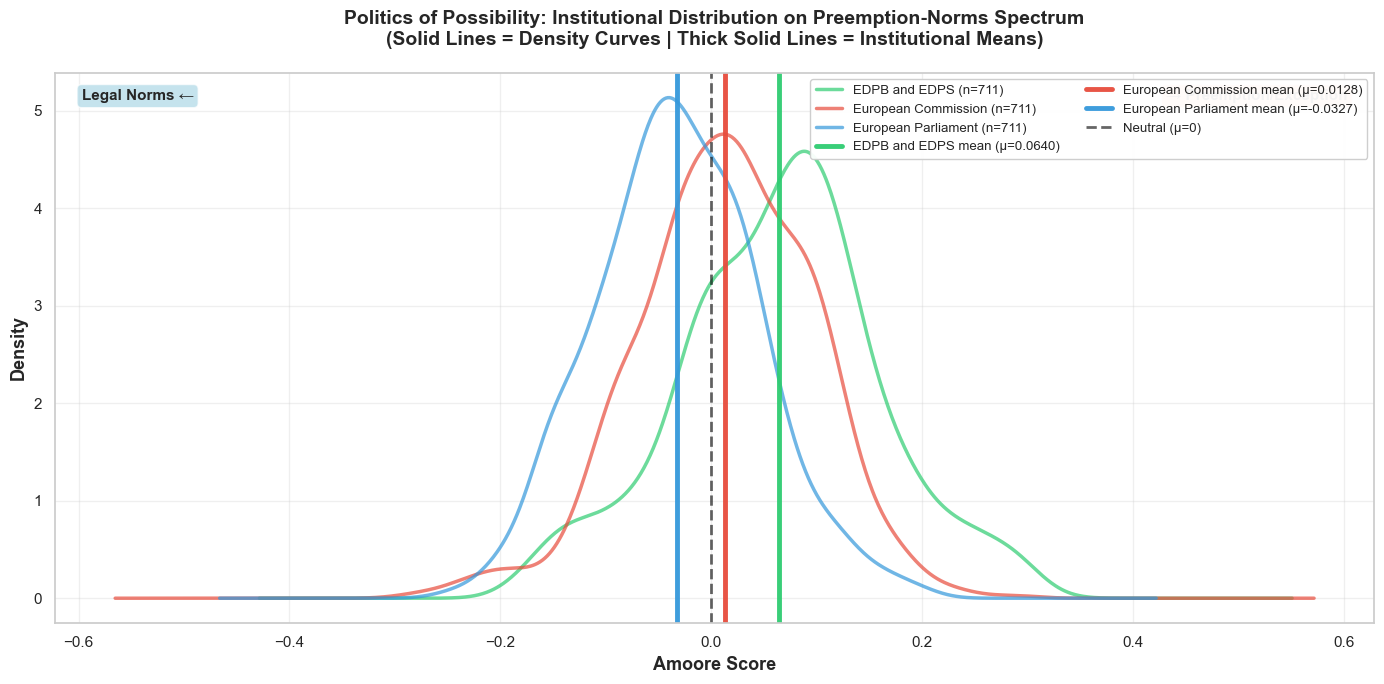

In [11]:
# AMOORE AXIS VISUALIZATION: Density Plot (KDE) WITH INSTITUTIONAL MEANS

print("\n" + "="*70)
print("GENERATING AMOORE AXIS DENSITY VISUALIZATION")
print("="*70)

fig, ax = plt.subplots(figsize=(14, 7))

# Create KDE plot for each institution AND store means
institutions_list = df_balanced['institution'].unique()
colors_map = {'European Commission': '#E74C3C', 'European Parliament': '#3498DB', 'EDPB and EDPS': '#2ECC71'}
institution_means = {}

for institution in sorted(institutions_list):
    inst_data = df_balanced[df_balanced['institution'] == institution]['amoore_score']
    color = colors_map.get(institution, '#95A5A6')
    mean_val = inst_data.mean()
    institution_means[institution] = mean_val
    
    # Create KDE plot
    inst_data.plot.kde(ax=ax, linewidth=2.5, label=f"{institution} (n={len(inst_data)})", 
                       color=color, alpha=0.7)
    
    print(f"\n{institution}:")
    print(f"  Samples: {len(inst_data)}")
    print(f"  Mean: {mean_val:.4f}")
    print(f"  Std: {inst_data.std():.4f}")

# Add vertical lines for institutional means with matching colors
print("\nAdding institutional mean markers to plot...")
for institution, mean_val in institution_means.items():
    color = colors_map.get(institution, '#95A5A6')
    ax.axvline(x=mean_val, color=color, linestyle='-', linewidth=3.5, alpha=0.95, 
               label=f"{institution} mean (μ={mean_val:.4f})")

# Add vertical line at 0 to show the neutral point
ax.axvline(x=0, color='black', linestyle='--', linewidth=2, alpha=0.6, label='Neutral (μ=0)')

# Labels and formatting
ax.set_xlabel('Amoore Score', fontsize=13, fontweight='bold')
ax.set_ylabel('Density', fontsize=13, fontweight='bold')
ax.set_title("Politics of Possibility: Institutional Distribution on Preemption-Norms Spectrum\n(Solid Lines = Density Curves | Thick Solid Lines = Institutional Means)", 
             fontsize=14, fontweight='bold', pad=20)

# Add annotations
ax.text(0.02, 0.97, 'Legal Norms ←', transform=ax.transAxes, fontsize=11, 
        verticalalignment='top', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))
ax.text(0.98, 0.97, '→ Preemption/Exception', transform=ax.transAxes, fontsize=11, 
        verticalalignment='top', horizontalalignment='right', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='lightsalmon', alpha=0.7))

# Create custom legend with smaller font and more compact layout
ax.legend(fontsize=9.5, loc='upper right', framealpha=0.95, ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/amoore_density_plot.png', dpi=300, bbox_inches='tight')
plt.show()


In [12]:
# Anchor discovery from candidate pool using same embedding space

print("\n" + "="*70)
print("ANCHOR DISCOVERY: COSINE-SIMILARITY RANKING FROM CANDIDATE POOL")
print("="*70)

pole_prompts = {
    "preemption": "preemptive security, risk detection, proactive intervention, algorithmic suspicion, possible future threat",
    "norms": "legal certainty, due process, proportionality, judicial oversight, fundamental rights, rule of law"
}

candidate_terms = [
    # preemption-like
    "detection", "risk-based", "automated suspicion", "proactive monitoring", "prevention",
    "possible threat", "indicators", "algorithmic surveillance", "preemptive intervention", "identification",
    "risk scoring", "profiling", "automated detection", "preventive action", "early warning",
    "threat assessment", "anomaly detection", "content scanning", "predictive policing", "suspicion",
    "mass scanning", "bulk monitoring", "proactive enforcement", "probabilistic inference", "high-risk user",

    # norms-like
    "due process", "proportionality", "legal certainty", "evidence-based", "judicial oversight",
    "fundamental rights", "rule of law", "probable cause", "limitation", "judicial warrant",
    "necessity", "data minimisation", "transparency", "accountability", "redress",
    "procedural safeguards", "independent review", "legality", "rights protection", "lawful basis",
    "non-discrimination", "presumption of innocence", "legal safeguards", "constitutional guarantees", "oversight"
]

candidate_terms = list(dict.fromkeys(candidate_terms))

candidate_emb = model.encode(candidate_terms)
preemption_prompt_emb = model.encode([pole_prompts["preemption"]])[0]
norms_prompt_emb = model.encode([pole_prompts["norms"]])[0]

sim_to_preemption = cosine_similarity(candidate_emb, [preemption_prompt_emb]).flatten()
sim_to_norms = cosine_similarity(candidate_emb, [norms_prompt_emb]).flatten()

anchor_df = pd.DataFrame({
    "term": candidate_terms,
    "sim_preemption": sim_to_preemption,
    "sim_norms": sim_to_norms
})
anchor_df["net_preemption_minus_norms"] = anchor_df["sim_preemption"] - anchor_df["sim_norms"]
anchor_df["net_norms_minus_preemption"] = anchor_df["sim_norms"] - anchor_df["sim_preemption"]

top_preemption = anchor_df.sort_values("net_preemption_minus_norms", ascending=False).head(10).copy()
top_norms = anchor_df.sort_values("net_norms_minus_preemption", ascending=False).head(10).copy()

# enforce disjoint sets
overlap = set(top_preemption["term"]).intersection(set(top_norms["term"]))
if overlap:
    top_norms = (
        anchor_df[~anchor_df["term"].isin(top_preemption["term"])]
        .sort_values("net_norms_minus_preemption", ascending=False)
        .head(10)
        .copy()
    )

amoore_anchors_auto = {
    "preemption": top_preemption["term"].tolist(),
    "norms": top_norms["term"].tolist()
}

print("\nTop 10 PREEMPTION anchors:")
print(top_preemption[["term", "sim_preemption", "sim_norms", "net_preemption_minus_norms"]].to_string(index=False))

print("\nTop 10 NORMS anchors:")
print(top_norms[["term", "sim_norms", "sim_preemption", "net_norms_minus_preemption"]].to_string(index=False))

print("\nAuto-selected anchors:")
print(amoore_anchors_auto)

os.makedirs("results", exist_ok=True)
anchor_df.sort_values("net_preemption_minus_norms", ascending=False).to_csv(
    "results/anchor_candidate_rankings.csv", index=False
)
print("\nSaved: results/anchor_candidate_rankings.csv")


ANCHOR DISCOVERY: COSINE-SIMILARITY RANKING FROM CANDIDATE POOL

Top 10 PREEMPTION anchors:
                    term  sim_preemption  sim_norms  net_preemption_minus_norms
         possible threat        0.505207   0.071110                    0.434097
       threat assessment        0.555725   0.130624                    0.425101
           early warning        0.463040   0.059609                    0.403431
     automated suspicion        0.499894   0.135270                    0.364624
algorithmic surveillance        0.456202   0.106976                    0.349226
    proactive monitoring        0.417527   0.085457                    0.332070
          high-risk user        0.463992   0.139227                    0.324765
 preemptive intervention        0.469804   0.190694                    0.279110
     automated detection        0.333328   0.071589                    0.261739
              prevention        0.386866   0.129933                    0.256933

Top 10 NORMS anchors:
    

In [13]:
# Non-destructive auto-anchor rerun + comparison to existing manual-anchor results

print("\n" + "="*70)
print("AUTO-ANCHOR AMOORE AXIS (NON-DESTRUCTIVE)")
print("="*70)

required_vars = ["model", "all_embeddings", "all_chunks", "chunk_to_doc", "chunk_to_institution", "amoore_anchors_auto"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"Missing required variables: {missing}")

amoore_embeddings_auto = {
    "preemption": model.encode(amoore_anchors_auto["preemption"]),
    "norms": model.encode(amoore_anchors_auto["norms"])
}

preemption_vector_auto = np.mean(amoore_embeddings_auto["preemption"], axis=0)
norm_vector_auto = np.mean(amoore_embeddings_auto["norms"], axis=0)

amoore_axis_auto = preemption_vector_auto - norm_vector_auto
amoore_axis_auto = amoore_axis_auto / np.linalg.norm(amoore_axis_auto)

amoore_scores_auto = []
amoore_sim_preemption_auto = []
amoore_sim_norms_auto = []

for emb in all_embeddings:
    amoore_scores_auto.append(np.dot(emb, amoore_axis_auto))
    amoore_sim_preemption_auto.append(cosine_similarity([emb], [preemption_vector_auto])[0, 0])
    amoore_sim_norms_auto.append(cosine_similarity([emb], [norm_vector_auto])[0, 0])

amoore_scores_auto = np.array(amoore_scores_auto)
amoore_sim_preemption_auto = np.array(amoore_sim_preemption_auto)
amoore_sim_norms_auto = np.array(amoore_sim_norms_auto)

df_balanced_auto = pd.DataFrame({
    "chunk_id": range(len(all_chunks)),
    "document": chunk_to_doc,
    "institution": chunk_to_institution,
    "chunk_text": [c[:100] + "..." if len(c) > 100 else c for c in all_chunks],
    "amoore_score_auto": amoore_scores_auto,
    "amoore_sim_preemption_auto": amoore_sim_preemption_auto,
    "amoore_sim_norms_auto": amoore_sim_norms_auto
})

auto_summary = (
    df_balanced_auto.groupby("institution")["amoore_score_auto"]
    .agg(["mean", "std", "median", "min", "max", "count"])
    .sort_index()
)
print("\nAuto-anchor institutional summary:")
print(auto_summary.to_string())

if "df_balanced" in globals() and "amoore_score" in df_balanced.columns:
    manual_means = df_balanced.groupby("institution")["amoore_score"].mean().rename("mean_manual")
    auto_means = df_balanced_auto.groupby("institution")["amoore_score_auto"].mean().rename("mean_auto")
    comparison = pd.concat([manual_means, auto_means], axis=1)
    comparison["delta_auto_minus_manual"] = comparison["mean_auto"] - comparison["mean_manual"]

    print("\nManual vs Auto mean comparison:")
    print(comparison.to_string())

    comparison.to_csv("results/amoore_institutional_comparison_manual_vs_auto.csv")
    print("Saved: results/amoore_institutional_comparison_manual_vs_auto.csv")

df_balanced_auto.to_csv("results/amoore_paragraph_projections_autoanchors.csv", index=False)
print("Saved: results/amoore_paragraph_projections_autoanchors.csv")


AUTO-ANCHOR AMOORE AXIS (NON-DESTRUCTIVE)

Auto-anchor institutional summary:
                         mean       std    median       min       max  count
institution                                                                 
EDPB and EDPS        0.053869  0.106166  0.059226 -0.220640  0.318396    711
European Commission -0.008613  0.092623 -0.001870 -0.369893  0.308647    711
European Parliament -0.051468  0.084911 -0.052958 -0.293108  0.212339    711

Manual vs Auto mean comparison:
                     mean_manual  mean_auto  delta_auto_minus_manual
institution                                                         
EDPB and EDPS           0.064033   0.053869                -0.010163
European Commission     0.012765  -0.008613                -0.021378
European Parliament    -0.032672  -0.051468                -0.018796
Saved: results/amoore_institutional_comparison_manual_vs_auto.csv
Saved: results/amoore_paragraph_projections_autoanchors.csv



GENERATING AMOORE DENSITY PLOT (EMPIRICAL AUTO-ANCHORS)

EDPB and EDPS:
  Samples: 711
  Mean (auto): 0.0539
  Std (auto): 0.1062

European Commission:
  Samples: 711
  Mean (auto): -0.0086
  Std (auto): 0.0926

European Parliament:
  Samples: 711
  Mean (auto): -0.0515
  Std (auto): 0.0849

Adding institutional mean markers to plot...


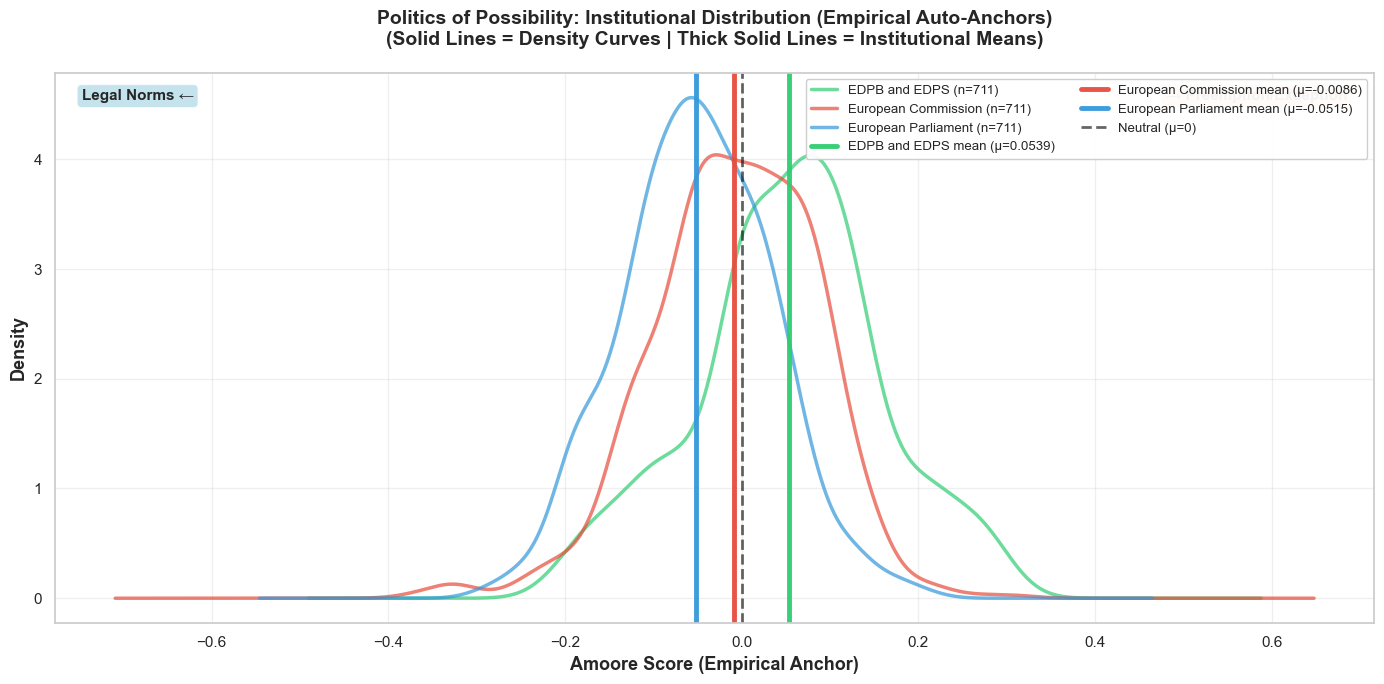


 Saved: results/amoore_density_plot_autoanchors.png


In [14]:
# Amoore density plot using empirically discovered anchors

print("\n" + "="*70)
print("GENERATING AMOORE DENSITY PLOT (EMPIRICAL AUTO-ANCHORS)")
print("="*70)

if "df_balanced_auto" not in globals():
    raise RuntimeError("df_balanced_auto not found. Run the auto-anchor rerun cell first.")

fig, ax = plt.subplots(figsize=(14, 7))

institutions_list = df_balanced_auto["institution"].unique()
colors_map = {
    "European Commission": "#E74C3C",
    "European Parliament": "#3498DB",
    "EDPB and EDPS": "#2ECC71"
}
institution_means_auto = {}

for institution in sorted(institutions_list):
    inst_data = df_balanced_auto[df_balanced_auto["institution"] == institution]["amoore_score_auto"]
    color = colors_map.get(institution, "#95A5A6")
    mean_val = inst_data.mean()
    institution_means_auto[institution] = mean_val

    inst_data.plot.kde(
        ax=ax,
        linewidth=2.5,
        label=f"{institution} (n={len(inst_data)})",
        color=color,
        alpha=0.7
    )

    print(f"\n{institution}:")
    print(f"  Samples: {len(inst_data)}")
    print(f"  Mean (auto): {mean_val:.4f}")
    print(f"  Std (auto): {inst_data.std():.4f}")

print("\nAdding institutional mean markers to plot...")
for institution, mean_val in institution_means_auto.items():
    color = colors_map.get(institution, "#95A5A6")
    ax.axvline(
        x=mean_val,
        color=color,
        linestyle="-",
        linewidth=3.5,
        alpha=0.95,
        label=f"{institution} mean (μ={mean_val:.4f})"
    )

ax.axvline(x=0, color="black", linestyle="--", linewidth=2, alpha=0.6, label="Neutral (μ=0)")

ax.set_xlabel("Amoore Score (Empirical Anchor)", fontsize=13, fontweight="bold")
ax.set_ylabel("Density", fontsize=13, fontweight="bold")
ax.set_title(
    "Politics of Possibility: Institutional Distribution (Empirical Auto-Anchors)\n"
    "(Solid Lines = Density Curves | Thick Solid Lines = Institutional Means)",
    fontsize=14, fontweight="bold", pad=20
)

ax.text(
    0.02, 0.97, "Legal Norms ←",
    transform=ax.transAxes, fontsize=11, verticalalignment="top", fontweight="bold",
    bbox=dict(boxstyle="round", facecolor="lightblue", alpha=0.7)
)
ax.text(
    0.98, 0.97, "→ Preemption/Exception",
    transform=ax.transAxes, fontsize=11, verticalalignment="top", horizontalalignment="right", fontweight="bold",
    bbox=dict(boxstyle="round", facecolor="lightsalmon", alpha=0.7)
)

ax.legend(fontsize=9.5, loc="upper right", framealpha=0.95, ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("results/amoore_density_plot_autoanchors.png", dpi=300, bbox_inches="tight")
plt.show()

print("\n Saved: results/amoore_density_plot_autoanchors.png")

In [15]:
# Manual vs Auto anchor means with 95% confidence intervals (side-by-side)

from scipy import stats

print("\n" + "="*70)
print("MANUAL VS AUTO: INSTITUTIONAL MEANS WITH 95% CIs")
print("="*70)

if "df_balanced" not in globals() or "amoore_score" not in df_balanced.columns:
    raise RuntimeError("Manual results not found: df_balanced['amoore_score'] is required.")
if "df_balanced_auto" not in globals() or "amoore_score_auto" not in df_balanced_auto.columns:
    raise RuntimeError("Auto results not found: df_balanced_auto['amoore_score_auto'] is required.")

institutions = sorted(set(df_balanced["institution"]).intersection(set(df_balanced_auto["institution"])))

rows = []
for inst in institutions:
    # Manual
    m = df_balanced.loc[df_balanced["institution"] == inst, "amoore_score"].dropna().values
    n_m = len(m)
    mean_m = float(np.mean(m)) if n_m > 0 else np.nan
    std_m = float(np.std(m, ddof=1)) if n_m > 1 else np.nan
    se_m = std_m / np.sqrt(n_m) if n_m > 1 else np.nan
    ci_m = stats.t.interval(0.95, df=n_m - 1, loc=mean_m, scale=se_m) if n_m > 1 else (np.nan, np.nan)

    # Auto
    a = df_balanced_auto.loc[df_balanced_auto["institution"] == inst, "amoore_score_auto"].dropna().values
    n_a = len(a)
    mean_a = float(np.mean(a)) if n_a > 0 else np.nan
    std_a = float(np.std(a, ddof=1)) if n_a > 1 else np.nan
    se_a = std_a / np.sqrt(n_a) if n_a > 1 else np.nan
    ci_a = stats.t.interval(0.95, df=n_a - 1, loc=mean_a, scale=se_a) if n_a > 1 else (np.nan, np.nan)

    rows.append({
        "institution": inst,
        "n_manual": n_m,
        "mean_manual": mean_m,
        "ci95_low_manual": ci_m[0],
        "ci95_high_manual": ci_m[1],
        "n_auto": n_a,
        "mean_auto": mean_a,
        "ci95_low_auto": ci_a[0],
        "ci95_high_auto": ci_a[1],
        "delta_auto_minus_manual": mean_a - mean_m
    })

ci_compare_df = pd.DataFrame(rows).sort_values("institution")

# Pretty print version
pretty = ci_compare_df.copy()
for col in [
    "mean_manual", "ci95_low_manual", "ci95_high_manual",
    "mean_auto", "ci95_low_auto", "ci95_high_auto",
    "delta_auto_minus_manual"
]:
    pretty[col] = pretty[col].map(lambda x: f"{x:.4f}" if pd.notnull(x) else "nan")

pretty["manual_95CI"] = "[" + pretty["ci95_low_manual"] + ", " + pretty["ci95_high_manual"] + "]"
pretty["auto_95CI"] = "[" + pretty["ci95_low_auto"] + ", " + pretty["ci95_high_auto"] + "]"

print("\nInstitution-level comparison:")
print(
    pretty[
        ["institution", "n_manual", "mean_manual", "manual_95CI", "n_auto", "mean_auto", "auto_95CI", "delta_auto_minus_manual"]
    ].to_string(index=False)
)

os.makedirs("results", exist_ok=True)
ci_compare_df.to_csv("results/amoore_ci_comparison_manual_vs_auto.csv", index=False)
print("\n Saved: results/amoore_ci_comparison_manual_vs_auto.csv")


MANUAL VS AUTO: INSTITUTIONAL MEANS WITH 95% CIs

Institution-level comparison:
        institution  n_manual mean_manual        manual_95CI  n_auto mean_auto          auto_95CI delta_auto_minus_manual
      EDPB and EDPS       711      0.0640   [0.0570, 0.0711]     711    0.0539   [0.0461, 0.0617]                 -0.0102
European Commission       711      0.0128   [0.0067, 0.0189]     711   -0.0086 [-0.0154, -0.0018]                 -0.0214
European Parliament       711     -0.0327 [-0.0383, -0.0270]     711   -0.0515 [-0.0577, -0.0452]                 -0.0188

 Saved: results/amoore_ci_comparison_manual_vs_auto.csv



PLOTTING MANUAL VS AUTO MEANS WITH 95% CIs


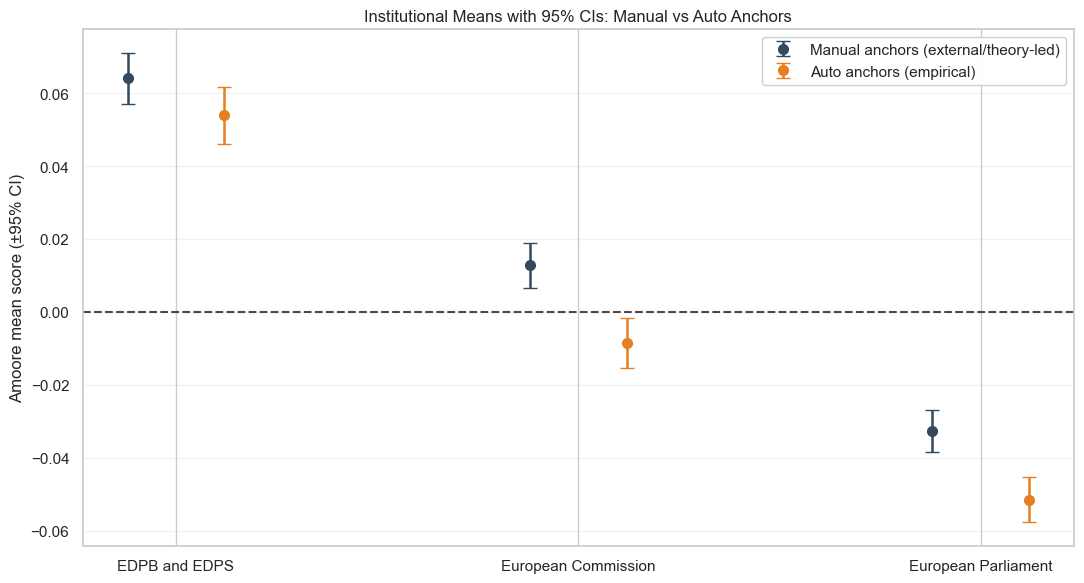


 Saved: results/amoore_ci_comparison_plot.png


In [16]:
# Visual comparison of institutional means with 95% CIs (manual vs auto)

print("\n" + "="*70)
print("PLOTTING MANUAL VS AUTO MEANS WITH 95% CIs")
print("="*70)

if "ci_compare_df" not in globals():
    raise RuntimeError("ci_compare_df not found. Run the CI table cell first.")

plot_df = ci_compare_df.sort_values("institution").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 6))

x = np.arange(len(plot_df))
offset = 0.12

# Manual
y_manual = plot_df["mean_manual"].values
yerr_manual = np.vstack([
    y_manual - plot_df["ci95_low_manual"].values,
    plot_df["ci95_high_manual"].values - y_manual
])

# Auto
y_auto = plot_df["mean_auto"].values
yerr_auto = np.vstack([
    y_auto - plot_df["ci95_low_auto"].values,
    plot_df["ci95_high_auto"].values - y_auto
])

ax.errorbar(
    x - offset, y_manual, yerr=yerr_manual,
    fmt="o", capsize=5, linewidth=1.8, markersize=7,
    color="#34495E", ecolor="#34495E", label="Manual anchors (external/theory-led)"
)
ax.errorbar(
    x + offset, y_auto, yerr=yerr_auto,
    fmt="o", capsize=5, linewidth=1.8, markersize=7,
    color="#E67E22", ecolor="#E67E22", label="Auto anchors (empirical)"
)

ax.axhline(0, color="black", linestyle="--", linewidth=1.5, alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(plot_df["institution"], rotation=0)
ax.set_ylabel("Amoore mean score (±95% CI)")
ax.set_title("Institutional Means with 95% CIs: Manual vs Auto Anchors")
ax.grid(True, axis="y", alpha=0.25)
ax.legend(framealpha=0.95)

plt.tight_layout()
os.makedirs("results", exist_ok=True)
plt.savefig("results/amoore_ci_comparison_plot.png", dpi=300, bbox_inches="tight")
plt.show()

print("\n Saved: results/amoore_ci_comparison_plot.png")

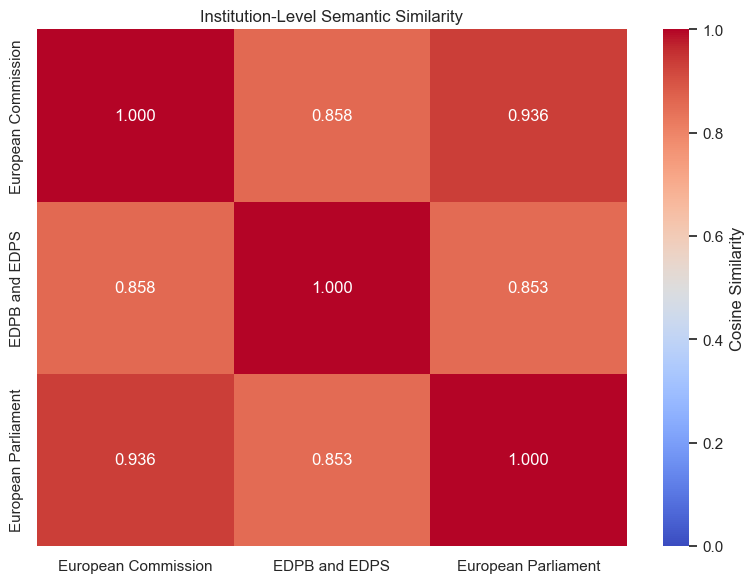

Heatmap saved to results/similarity_heatmap.png


In [17]:
# 6. HEATMAP OF DOCUMENT SIMILARITY

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(similarity_df, annot=True, fmt='.3f', cmap='coolwarm', 
            vmin=0, vmax=1, cbar_kws={'label': 'Cosine Similarity'}, ax=ax)
ax.set_title('Institution-Level Semantic Similarity')
plt.tight_layout()
plt.savefig('results/similarity_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("Heatmap saved to results/similarity_heatmap.png")